Exercise 1: Implement Simple Linear Regression

Use the computers.csv dataset and perform the following activities:

Dataset contains the details of time taken to repair a computer, given the number of units to be repaired.

Dataset: Download from drive link

Build Regression model using Scikit-Learn Library(Model 3).
Set the 'Units' column as the input data or predictor column
Set the 'Minutes' column as the output data
Importing the required class -  LinearRegression
Creating a linear regression model
Fitting the model to the data
Fetching intercept and coefficient
Creating Linear Regression model with calculated coefficient and intercept.
Add the above model to the dataframe for Visualization.
Visualize Models using pyplot.
Compute the Coefficient of Determination to find accuracy.

In [1]:
#Step 1: Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:
#2: Load the Dataset
df = pd.read_csv("./data/computers.csv")
print(df.head())


   Units  Minutes
0      1       23
1      2       29
2      3       49
3      4       64
4      4       74


In [3]:
#3: Define Input and Output
X = df[['Units']]      
y = df['Minutes']      


In [4]:
#4: Create Linear Regression Model
model = LinearRegression()


In [5]:
#5: Fit the Model
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
#6: Fetch Intercept and Coefficient
intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept (b0):", intercept)
print("Coefficient (b1):", coefficient)


Intercept (b0): 4.161654135338296
Coefficient (b1): 15.508771929824569


In [7]:
#7: Add Predicted Values to DataFrame
df['Predicted_Minutes'] = model.predict(X)
print(df.head())


   Units  Minutes  Predicted_Minutes
0      1       23          19.670426
1      2       29          35.179198
2      3       49          50.687970
3      4       64          66.196742
4      4       74          66.196742


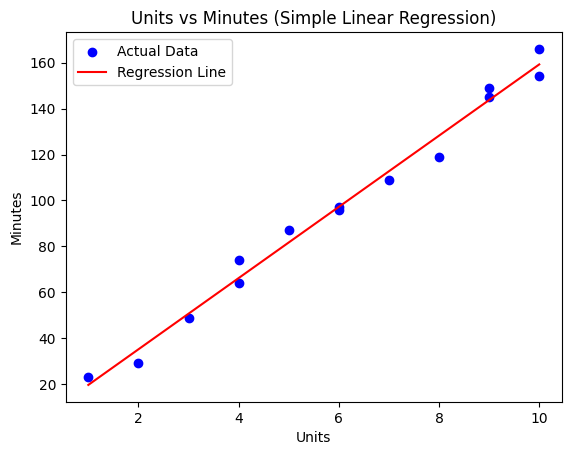

In [8]:
#8: Visualize the Regression Line
plt.scatter(df['Units'], df['Minutes'], color='blue', label='Actual Data')
plt.plot(df['Units'], df['Predicted_Minutes'], color='red', label='Regression Line')
plt.xlabel('Units')
plt.ylabel('Minutes')
plt.title('Units vs Minutes (Simple Linear Regression)')
plt.legend()
plt.show()


In [9]:
#9: Compute Coefficient of Determination (R²)
r2 = r2_score(y, df['Predicted_Minutes'])
print("R² Score:", r2)


R² Score: 0.9874371980620736


Exercise 2: Multiple Linear Regression Model

std_marks_data.csv

To understand Multiple Linear Regression, let us consider the student marks dataset.

This model helps us to predict the marks of the students using the previous dataset.

The inputs are hours(time spent to study) ,age(present age) and internet(weather the internet is available or not), by using these 3 input fields we are predicting the marks of the students.

Observe data and do some preprocessing.
Find no. of missing values.
Fill mean value in place of NaN value so NaN value does not affect accuracy.
Segregate input and output.
Prepare model.
Test model with new input data.

In [10]:
#1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [12]:
#2: Load Dataset
df = pd.read_csv("./data/std_marks_data.csv")
print(df.head())
print(df.info())


   hours  age  internet  marks
0   6.84   15         0  78.64
1   6.56   20         1  88.80
2    NaN   21         1  88.90
3   8.67   22         1  98.99
4   7.55   17         1  92.34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     288 non-null    float64
 1   age       300 non-null    int64  
 2   internet  300 non-null    int64  
 3   marks     300 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 9.5 KB
None


In [13]:
#3: Check Missing Values
print("Missing values in each column:\n")
print(df.isnull().sum())


Missing values in each column:

hours       12
age          0
internet     0
marks        0
dtype: int64


In [15]:
#4: Fill NaN Values with Mean
df.fillna(df.mean(numeric_only=True), inplace=True)
print("\nAfter filling missing values:\n")
print(df.isnull().sum())



After filling missing values:

hours       0
age         0
internet    0
marks       0
dtype: int64


In [17]:
#5: Convert Categorical Data (Internet) to Numeric
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})
print("\nAfter converting 'internet' column:\n")
print(df.head())


After converting 'internet' column:

      hours  age  internet  marks
0  6.840000   15       NaN  78.64
1  6.560000   20       NaN  88.80
2  5.494514   21       NaN  88.90
3  8.670000   22       NaN  98.99
4  7.550000   17       NaN  92.34


In [18]:
#6: Segregate Input and Output
X = df[['hours', 'age', 'internet']]   
y = df['marks']                        


In [22]:
print(df.isnull().sum())


hours         0
age           0
internet    300
marks         0
dtype: int64


In [24]:
df.replace("?", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)
df.dropna(inplace=True)


In [26]:
df['hours'] = pd.to_numeric(df['hours'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['marks'] = pd.to_numeric(df['marks'], errors='coerce')
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   hours     0 non-null      float64
 1   age       0 non-null      int64  
 2   internet  0 non-null      float64
 3   marks     0 non-null      float64
dtypes: float64(3), int64(1)
memory usage: 0.0 bytes
None


In [27]:
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})


In [28]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

hours       0
age         0
internet    0
marks       0
dtype: int64


In [34]:
print(X.isnull().sum())
print(y.isnull().sum())
print(X.dtypes)


hours       0
age         0
internet    0
dtype: int64
0
hours       float64
age           int64
internet      int64
dtype: object


In [35]:
import numpy as np


df.replace("?", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)


In [36]:
df['internet'] = df['internet'].map({'Yes': 1, 'No': 0})


In [37]:
X = df[['hours', 'age', 'internet']]
y = df['marks']


In [38]:
print(X.isnull().sum())
print(X.dtypes)


hours       0
age         0
internet    0
dtype: int64
hours       float64
age           int64
internet      int64
dtype: object


In [40]:
print("Missing values in X:\n", X.isnull().sum())
print("Missing values in y:\n", y.isnull().sum())

print("Data types:\n", X.dtypes)





Missing values in X:
 hours       0
age         0
internet    0
dtype: int64
Missing values in y:
 0
Data types:
 hours       float64
age           int64
internet      int64
dtype: object


In [ ]:
#Step 8: Train the Multiple Linear Regression Model
# LinearRegression is already imported in an earlier cell

if len(X) == 0 or len(y) == 0:
	print("Error: No data available for training. Please check data loading and preprocessing.")
else:
	model = LinearRegression()
	model.fit(X, y)
	print("Model trained successfully ✅")


ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LinearRegression.